In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import xarray as xr
from glob import glob
import os
from netCDF4 import Dataset
import pandas as pd
from datetime import datetime, date, timedelta
from pathlib import Path
import scipy
import scipy.ndimage
from mpl_toolkits.axes_grid1 import ImageGrid
import math

from mpl_toolkits.axes_grid1 import make_axes_locatable

#constants
t = 6 # time index

#Input
input_dir = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/full-area/")
source_input_dir = Path("/mnt/stor-pool-01/projects/heus/EUREC4A_Eulerian/Feb_1st_12day_cdnc70_nudge/")

#variables
z_i = np.empty(4, dtype=int)
z_selected = np.empty(4, dtype=object)
z_s_str = np.empty(4, dtype=object)

z_i_ql = np.empty(4, dtype=int)
z_selected_ql = np.empty(4, dtype=object)
z_s_str_ql = np.empty(4, dtype=object)

In [2]:
#load datasets
ds_ql_mask = xr.open_dataset(input_dir / "ql_mask.nc", decode_times=False)
ds_w_mask = xr.open_dataset(input_dir / "w_mask.nc", decode_times=False)
ds_shell_mask = xr.open_dataset(input_dir / "shell_mask.nc", decode_times=False)
ds_shell_labels = xr.open_dataset(input_dir / "shell_labels.nc", decode_times=False)

ds_ql = xr.open_dataset(source_input_dir / "ql.nc", decode_times=False,chunks={'time': 1})
ds_w = xr.open_dataset(source_input_dir / "w.nc", decode_times=False,chunks={'time': 1})
ds_w = ds_w.rename({'zh':'z'}).interp(z=ds_ql.z)

In [3]:
w_slice = ds_w.isel(time=t).sel(z=slice(0, 100))
z_0_coverage_w = w_slice.w.min(dim='z').compute()
coverage_percentage_w = ((z_0_coverage_w < -0.25).sum().item() / z_0_coverage_w.size) * 100

In [4]:
shell_labels_slice = ds_shell_labels.isel(time=t).sel(z=slice(0, 100))
shell_mask_slice = ds_shell_mask.isel(time=t).sel(z=slice(0, 100))
w_mask_slice = ds_w_mask.isel(time=t).sel(z=slice(0, 100))
z_0_coverage = shell_labels_slice.shell_labels.max(dim='z')
z_0_coverage_mask = shell_mask_slice.shell_mask.max(dim='z')
z_0_coverage_w_mask = w_mask_slice.w_mask.max(dim='z')
coverage_percentage = ((z_0_coverage > 0).sum().item() / z_0_coverage.size) * 100
coverage_percentage_mask = ((z_0_coverage_mask > 0).sum().item() / z_0_coverage_mask.size) * 100
coverage_percentage_w_mask = ((z_0_coverage_w_mask > 0).sum().item() / z_0_coverage_w_mask.size) * 100

In [5]:
coverage_percentage

0.0

In [6]:
coverage_percentage_mask

8.884811401367188

In [7]:
coverage_percentage_w

10.80322265625

In [8]:
coverage_percentage_w_mask

10.80322265625

In [ ]:
z_0_coverage.where(z_0_coverage > 0).plot(cmap='viridis', vmin=0, vmax=1)

In [ ]:
z_0_coverage_mask.where(z_0_coverage_mask > 0).plot(cmap='viridis', vmin=0, vmax=1)

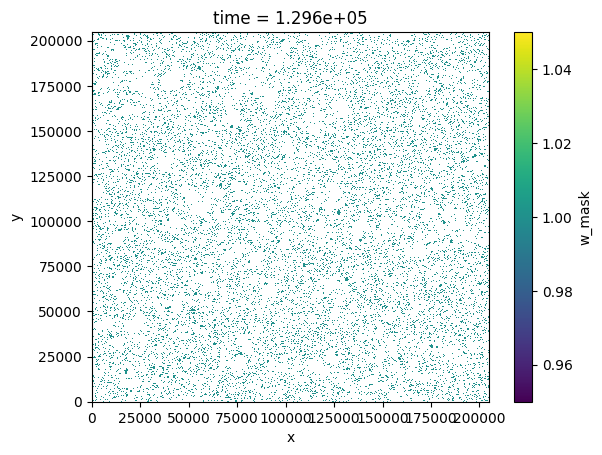

In [9]:
z_0_coverage_w_mask.where(z_0_coverage_w_mask > 0).plot(x="x", y="y", cmap="viridis")

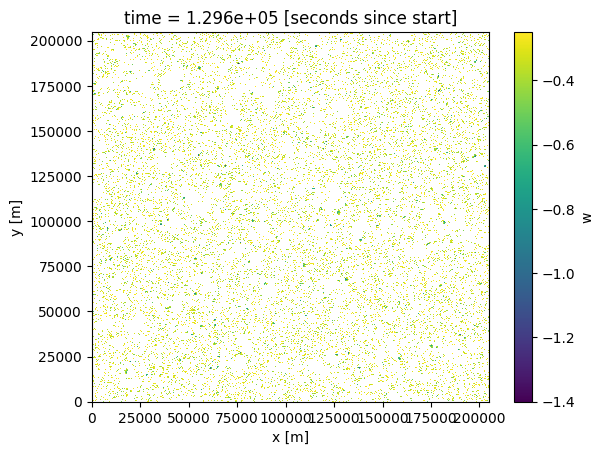

In [10]:
z_0_coverage_w.where(z_0_coverage_w < -0.25).plot(x="x", y="y", cmap="viridis")